# PCA и понижении размерности  

Матвей Аношин и Нина Коновалова

### 0. Короткая математическая справка буквально на полминуты-минуту:

<details>
  <summary>Линейность отображения (свойства) </summary>
  
  1. $F(\alpha X) = \alpha F(X)$
  2. $F(X + Y) = F(X) + F(Y)$
  
  Линейное отображение может быть задано матрицей
  
  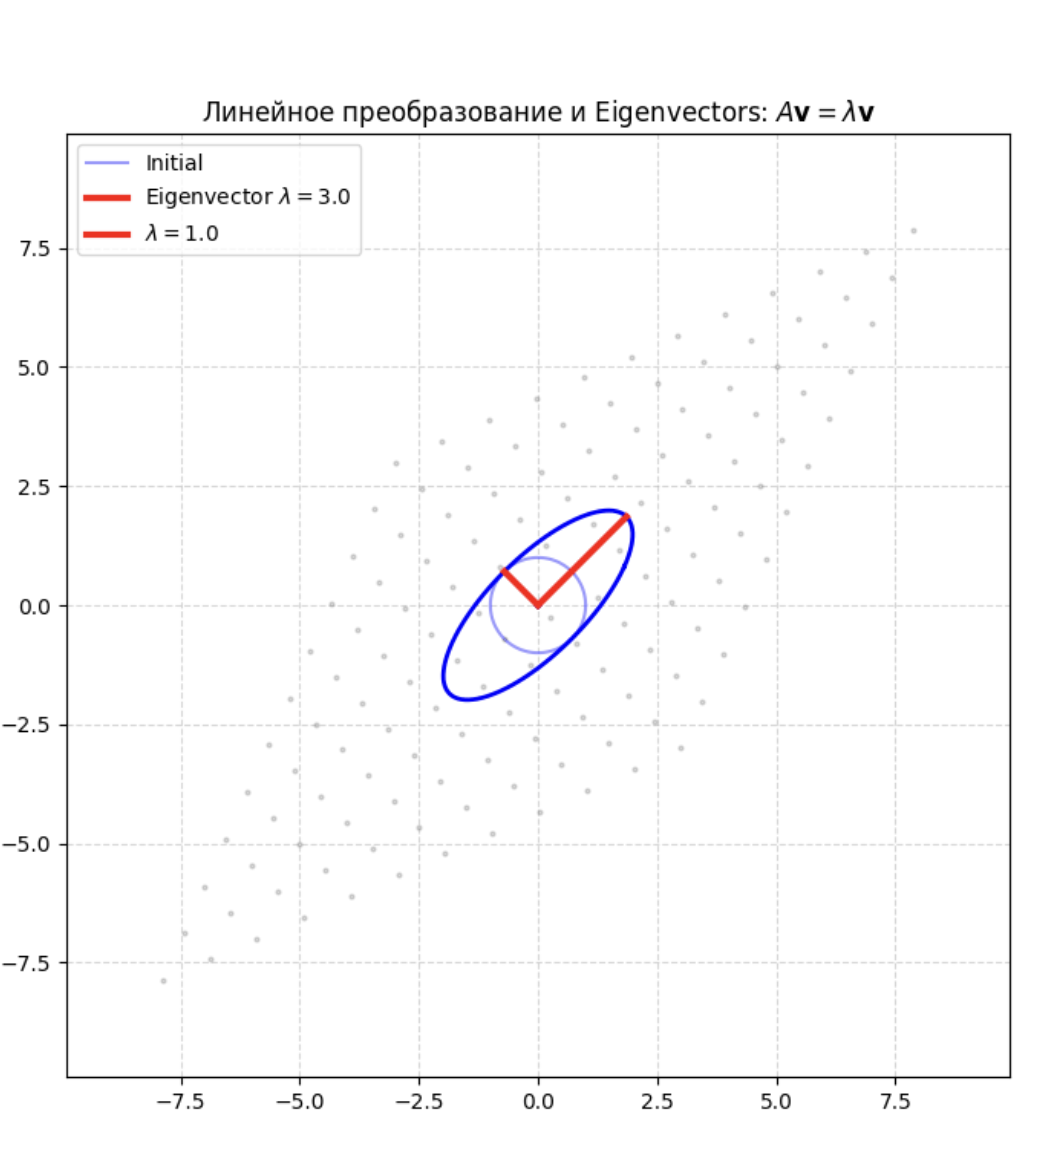

</details>

<details>
  <summary>Ортогональность матрицы (определение) </summary>
  
  $$U^TU=UU^T=E$$
  
  где $E$ - единичная матрица
</details>

<details>
  <summary>Спектральное разложение </summary>
  
  Для квадратной матрицы $X \in \mathbb{R}^{n \times n}$ $: \exists \Omega, V:$

  $$X = V \Omega V^{-1}$$

  где $\Omega$ - диагональная матрица на собственных* числах матрицы X, $V$ - квадратная матрица перехода

  > Дополнительные определения (для удобства): $v_i$ - не нулевой вектор, называется собственным для $X$, если $\exists \lambda_i: Xv_i = \lambda_i v_i$. $\lambda_i$ в свою очередь называется собственным числом матрицы $X$.

  При спектральном разложение, матрица $V$ составлена из собственных векторов $V=(v_i)$, взятых как столбцы

</details>


<details>
  <summary>Singular Value Decomposition (SVD) </summary>

  Для любой матрицы $X \in \mathbb{R}^{m\times n}$ $: \exists U, V:$

  $$X = U \Sigma V^T$$

  где $U, V$ - ортогональные, а $\Sigma$ - матрица составленная из 0 и $k = \mathrm{rank}(X)$ сингулярных чисел стоящих на **диагонале**. По построению и свойствам сингулярных чисел $$\Sigma = \mathrm{diag}(\sigma_1, \ldots, \sigma_k, 0, \ldots, 0)$$

  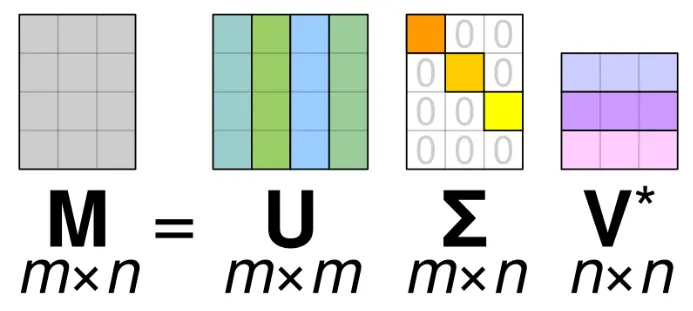

  ###### image source: https://medium.com/@krasniuk-ai/the-math-behind-the-singular-value-decomposition-a847abf22fc1

  Важный факт:

  $$ X^T X = V \Sigma^T U^T U \Sigma V^T = V \Sigma^2 V^T$$

  Иначе говоря - для квадратной матрицы $X$, ее $\sigma_i$ сингулярное число связано с собсвтенным числом $\lambda_i=\sigma_i^2$
  

</details>




<details>
  <summary>Нормы (свойства) </summary>

  1. Норма Фробениуса (aka спектральная норма) для матрицы $A \in \mathbb{R}^{m \times n}$:
  
  $$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\mathrm{tr}(A^T A)}$$
  
  Ключевое свойство: **инвариантность относительно ортогональных преобразований**. Для ортогональных U, V:
  
  $$\|UAV\|_F = \|A\|_F$$
   
</details>

### 1. Поехали!

Зададим наш рабочий объект (датасет) как невырожденный набор признаков $X \in \mathbb{R}^{N\times f}$ где $N$ - кол-во точек в датасете, $f$ - кол-во фич в датасете (для удобства нотации, $f < N$). Задача понижения размерности (dimensionality reduction) в простом случае ставится как проблема **обучения без учителя (unsupervised learning)**, с целью построить **ортогональное** отображение $\mathscr{L}$

$$ \mathscr{L}: X  \rightarrow X' $$

где $X \in \mathbb{R}^{N\times f}$, $X' \in  \mathbb{R}^{N\times p}$, а $p$ - новое колличество (заданных или отобранных) признаков ($p<f$).  

>Суть построенного отображения в том, что бы безусловно сохранить репрезентативность данных, или же отобрать самые важные признаки если их излишне много (e.g., 100+). Критерием хорошего отбора, может быть близость (по заданной норме $||\cdot||$) $X'$ и исходной $X$



Ставя задачу формально:

$$X' = \arg\min_{\mathrm{rank}(A) \leq p} ||X - A||_F$$


### 2. Упрощенные вывод и доказательство:

$$ ||X - X'||_F = ||U^T(X - X')V||_F = ||U^T(U \Sigma V^T - X')V||_F = ||\Sigma - U^TX'V ||_F $$

Итак, задача свелась к минимизации:

$$\min_{X':\, \mathrm{rank}(X') \leq p} ||\Sigma - U^T X' V||_F,$$

обозначим $M = U^T X' V$.

>Раз $X'$ имеет ранг $\leq p$, то и $M$ имеет ранг $\leq p$.

Нам нужно подобрать матрицу ранга $\leq p$, наиболее близкую к диагональной $\Sigma$. Не трудно видеть, раз $\Sigma$ составлена элементами $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$, то минимум достигается, когда $M$ совпадает с $\Sigma$ на первых $p$ диагональных позициях и равна нулю на остальных:

$$M^* = \Sigma_p = \mathrm{diag}(\sigma_1, \ldots, \sigma_p, 0, \ldots, 0)$$

Возвращаясь к $X'$:

$$M^* = U^T X' V \implies X' = U \Sigma_p V^T$$

##### И таким образом, сжатие до $p$ признаков происходит усечением SVD, или выбором первых $p$ сингулярных чисел!
>Этот факт называется теоремой Эккарта-Янга

Из важного, спектральная норма дает интуитивную оценку ошибки приближения матрицы X через остаточные сингулярные числа:


$$||X - X'_p||_F = \sum_{i=p+1}^{f} \sigma_i^2$$


#### Задача 1: Относительная ошибка dimensionality reduction на Numpy

Мы прыгаем c места в карьер, и хотим закрепить полученные знания сеансом программирования. Задание:

1. Зафиксируйте manual seed 42 в Numpy
2. Сгенериуйте случайную матрицу $X$ размером $250\times15$
3. Постройте для нее SVD
4. Постройте график относительной ошибки аппроксимации (w.r.t спектральной норме) матрицы $X$ новой матрицей $X'_p$, где p изменяется от 1 до 15
5. Постройте аналогичный график для данных $X$ из датасета [Ирисы Фишера](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0) (working since 1936). Легко взять их можно с помощью `from sklearn.datasets import load_iris`

> В случае, если вы подзабыли (или просто не знали) как делать какую-то часть задания, используйте только документацию Numpy через [браузер](https://numpy.org/doc/2.4/reference/index.html#reference) или ноутбук

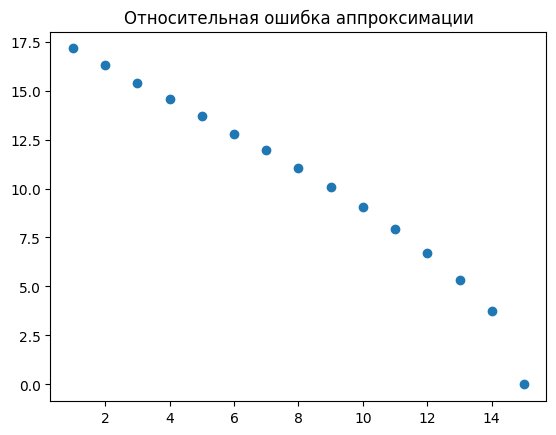

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

X = np.random.random_sample((250, 15))
U, S, Vt = np.linalg.svd(X, full_matrices=False)

p_r = range(1, 16)
er = []

for p in p_r:
    S_p = np.zeros((S.shape[0], S.shape[0]))
    for i in range(p):
        S_p[i][i] = S[i]

    X_p = U @ S_p @ Vt

    A = X - X_p

    er.append(np.sqrt(np.linalg.trace(A.T @ A)))

plt.title("Относительная ошибка аппроксимации")
plt.scatter(p_r, er)
plt.show()



(150, 4)


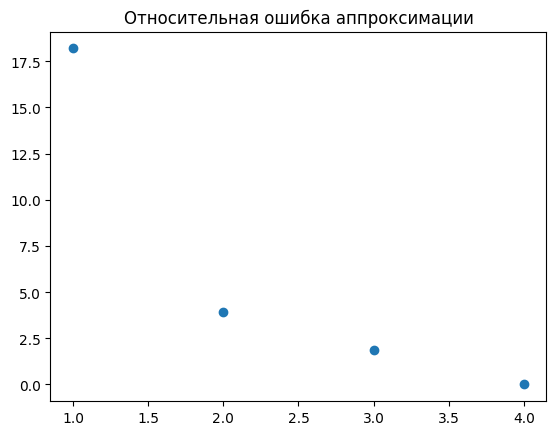

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

np.random.seed(42)

iris = load_iris()

X = iris.data
print(X.shape)
U, S, Vt = np.linalg.svd(X, full_matrices=False)

p_r = range(1, S.shape[0] + 1)
er = []

for p in p_r:
    S_p = np.zeros((S.shape[0], S.shape[0]))
    for i in range(p):
        S_p[i][i] = S[i]

    X_p = U @ S_p @ Vt

    A = X - X_p

    er.append(np.sqrt(np.linalg.trace(A.T @ A)))

plt.title("Относительная ошибка аппроксимации")
plt.scatter(p_r, er)
plt.show()


### 3. Principal Component Analysis (PCA)


PCA или метод главных компонент работает на ковариационной матрице признаков:

$$ X^TX = \mathrm{cov}(f_i, f_j) $$

Она является квадратной, и проделав для нее спектральное разложение, мы переводим ее к диагональному виду, котором как очевидно, признаки максимально не скоррелированы :). Если вам интутивно кажется, что именно в таком виде надо отбирать признаки - вы правы

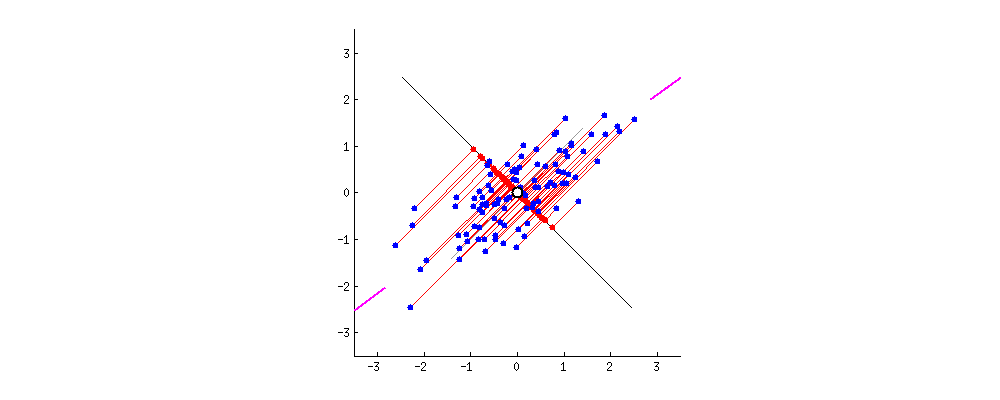

>То есть, мы всегда можем перейти от текущего набора признаков к некоррелированным друг к другу признакам, что существенно повысит обусловленность задачи

Более того, собственные числа $\Sigma$ для $X^TX$ матрицы (или сингулярные числа  $\sqrt{\Sigma}$ матрицы
X) - будут скоррелированы с важностью того или иного признака (чем больше дисперсия признака, тем он «важнее»). Таким образом мы можем даже отсекать «неважные» признаки!


> Важное наблюдение, признаки нужно standard-scale-ить перед PCA

#### Задача 2: Построение базового PCA на Numpy

Продолжаем программировать. Реализуйте шаги алгоритма PCA на Python:

1. Постройте графики для собственных чисел матрицы ковариаций построенной на признаках датасета Breast Cancer (`load_breast_cancer()`) от их порядкового номера. Какое оптимальное число главных компонент стоит выбрать?

2. Имплементация PCA
+ Программа минимум: сделать функцию `pca_transform(X, n_components) -> np.array`, возвращающей обработанные данные

+ Программа максимум: сделать класс `PCA`, который принимает `n_components` при инициализации. У класса должны быть методы `fit_transform` и `inverse_transform`

(569, 30)


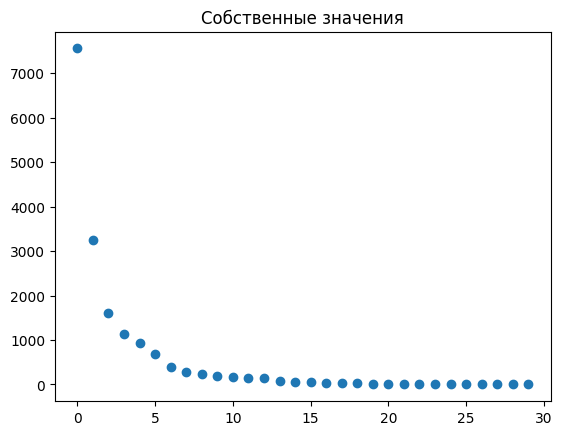

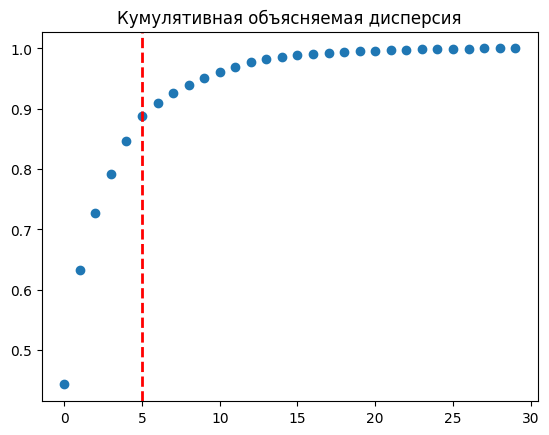

array([[ 1.49461904, -1.70923883, -0.12385827,  0.63216966, -1.0919561 ],
       [-0.48711012, -1.6758375 , -0.58141874,  1.40097492, -0.25520449],
       [ 0.05716744, -1.71350094, -0.67996644, -0.00952931,  0.71182324],
       ...,
       [-0.12929437, -0.33818126, -0.55657947, -0.39256208,  0.40645703],
       [ 1.68561193, -2.14428549, -0.5500337 , -1.53462788,  1.44788422],
       [-0.20801258,  0.5204554 ,  0.62513487,  0.08211803, -1.7227386 ]],
      shape=(569, 5))

In [28]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

lbc = load_breast_cancer()

def pca_transform(X, n_components):
    ss = StandardScaler()
    X = ss.fit_transform(X)

    X_c = X.T @ X

    eigenvalues, eigenvectors = np.linalg.eig(X_c)

    e_v_ind = []
    for i in range(len(eigenvalues)):
        e_v_ind.append((eigenvalues[i], i))
    e_v_ind = sorted(e_v_ind, reverse=True)

    plt.title("Собственные значения")
    plt.scatter(range(len(eigenvalues)), np.sort(eigenvalues)[::-1])
    plt.show()

    e_v_s = sum(eigenvalues)
    prefs = []
    cur_pref = 0
    for i in e_v_ind:
        cur_pref += i[0]
        prefs.append(cur_pref / e_v_s)

    plt.title("Кумулятивная объясняемая дисперсия")
    plt.scatter(range(len(prefs)), prefs)
    plt.axvline(x=n_components, color='red', linestyle='--', linewidth=2)
    plt.show()

    w = []
    for i in range(n_components):
        w.append(np.array(eigenvectors[e_v_ind[i][1]]))
    w = np.array(w)

    # print(w)
    # print(w.shape, X.shape)

    return X @ w.T

print(lbc.data.shape)
pca_transform(lbc.data, 5)

#### Задача 3: PCA в Sklearn

В проде, конечно, никто особо не использует самодельный PCA:)

1. Изучите документацю [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) из Sklearn
2. Примените его на датасете Breast Cancer
3. Сравните свою имплементацию с встроенной :)

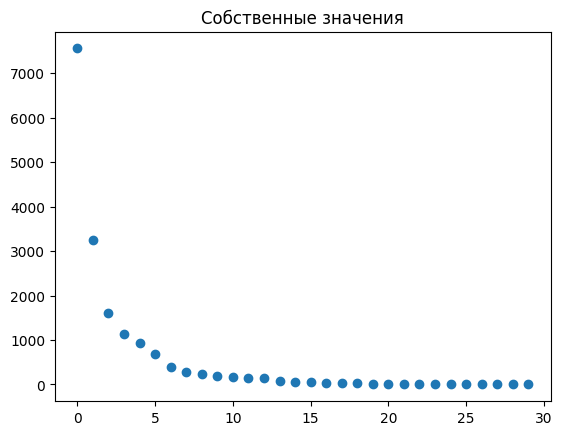

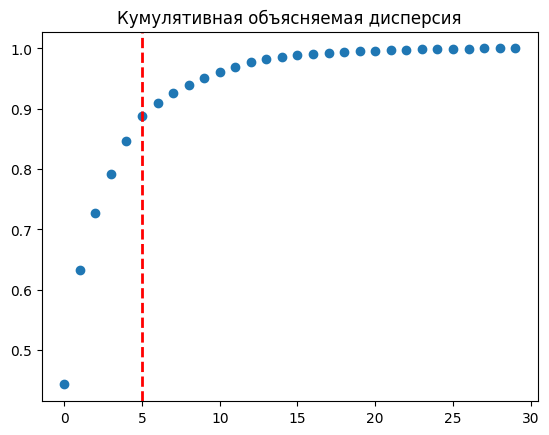

(np.float64(-3.055902197957039e-10), 'Разница sklearn PCA с моим')

In [29]:
from sklearn.decomposition import PCA

X = lbc.data

pca = PCA(n_components=5)
X_pca_1 = pca.fit_transform(X)
X_pca_2 = pca_transform(X, 5)

(X_pca_1 - X_pca_2).sum().sum(), "Разница sklearn PCA с моим"